In [1]:
# Import the libraries
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio import features
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject, Resampling
import geopandas as gpd
from tqdm.notebook import tqdm
import folium
from folium import plugins

In [2]:
import os
import glob

folder_path = "burned_area"

folder_list = glob.glob(os.path.join(folder_path, '*'))

print(f"พบไฟล์ทั้งหมด: {len(folder_list)} ไฟล์\n")


for file_path in folder_list:

    file_name = os.path.basename(file_path)
    print(file_name)

พบไฟล์ทั้งหมด: 12 ไฟล์

Burned_S2_20260201_20260210
Burned_S2_20260101_20260110
Burned_S2_20260121_20260131
Burned_S2_20260411_20260420
Burned_S2_20260211_20260220
Burned_S2_20260111_20260120
Burned_S2_20260301_20260310
Burned_S2_20260421_20260430
Burned_S2_20260221_20260228
Burned_S2_20260401_20260410
Burned_S2_20260311_20260320
Burned_S2_20260321_20260331


In [5]:
import geopandas as gpd
import pandas as pd
import glob, os
from shapely.geometry import mapping
import warnings

base_path = 'burned_area'
shapefile_list = glob.glob(os.path.join(base_path, '**', '*.shp'), recursive=True)
print(f"พบไฟล์ทั้งหมด: {len(shapefile_list)} ไฟล์")

TARGET_CRS = 'EPSG:32647'

gdfs = []
for file in shapefile_list:
    filename = os.path.basename(file)
    print(f"กำลังอ่าน: {filename}")
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            gdf = gpd.read_file(file, engine='pyogrio')

        # ตัด Z dimension ออก (แก้ปัญหา Measured 3D Polygon)
        gdf['geometry'] = gdf['geometry'].apply(
            lambda geom: geom if geom is None else geom.__class__(
                [(x, y) for x, y, *_ in geom.exterior.coords]
            ) if geom.geom_type == 'Polygon' else geom
        )

        print(f"  CRS เดิม: {gdf.crs}")
        gdf = gdf.to_crs(TARGET_CRS)

        parts = filename.replace('.shp', '').split('_')
        if len(parts) >= 4:
            gdf['start_date']  = pd.to_datetime(parts[2], format='%Y%m%d')
            gdf['end_date']    = pd.to_datetime(parts[3], format='%Y%m%d')
            gdf['period_name'] = filename.replace('.shp', '')

        gdfs.append(gdf)
        print(f"  ✅ สำเร็จ ({len(gdf):,} แถว)")

    except Exception as e:
        print(f"  ❌ error: {e}")

merged_gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True),
                               geometry='geometry', crs=TARGET_CRS)
print(f"\n✅ รวมสำเร็จ ทั้งหมด: {len(merged_gdf):,} แถว")

display(merged_gdf[['period_name', 'start_date', 'end_date', 'geometry']].head())

พบไฟล์ทั้งหมด: 12 ไฟล์
กำลังอ่าน: Burned_S2_20260201_20260210.shp
  CRS เดิม: EPSG:4326
  ✅ สำเร็จ (29,566 แถว)
กำลังอ่าน: Burned_S2_20260101_20260110.shp
  CRS เดิม: EPSG:4326
  ✅ สำเร็จ (29,671 แถว)
กำลังอ่าน: Burned_S2_20260121_20260131.shp
  CRS เดิม: EPSG:4326
  ✅ สำเร็จ (24,165 แถว)
กำลังอ่าน: Burned_S2_20260411_20260420.shp
  CRS เดิม: EPSG:4326
  ✅ สำเร็จ (429,390 แถว)
กำลังอ่าน: Burned_S2_20260211_20260220.shp
  CRS เดิม: EPSG:4326
  ✅ สำเร็จ (31,733 แถว)
กำลังอ่าน: Burned_S2_20260111_20260120.shp
  CRS เดิม: EPSG:4326
  ✅ สำเร็จ (23,481 แถว)
กำลังอ่าน: Burned_S2_20260301_20260310.shp
  CRS เดิม: EPSG:32647
  ✅ สำเร็จ (162,131 แถว)
กำลังอ่าน: Burned_S2_20260421_20260430.shp
  CRS เดิม: EPSG:4326
  ✅ สำเร็จ (395,668 แถว)
กำลังอ่าน: Burned_S2_20260221_20260228.shp
  CRS เดิม: EPSG:4326
  ✅ สำเร็จ (227,312 แถว)
กำลังอ่าน: Burned_S2_20260401_20260410.shp
  CRS เดิม: EPSG:4326
  ✅ สำเร็จ (307,512 แถว)
กำลังอ่าน: Burned_S2_20260311_20260320.shp
  CRS เดิม: EPSG:4326
  ✅ สำเร็จ (28,6

,period_name,start_date,end_date,geometry
0,Burned_S2_20260201_20260210,2026-02-01,2026-02-10,"POLYGON ((542224.267 1246290.000, 542229.728 1..."
1,Burned_S2_20260201_20260210,2026-02-01,2026-02-10,MULTIPOLYGON Z (((558084.302 1277465.870 0.000...
2,Burned_S2_20260201_20260210,2026-02-01,2026-02-10,"POLYGON ((562980.000 1239240.000, 562980.000 1..."
3,Burned_S2_20260201_20260210,2026-02-01,2026-02-10,"POLYGON ((499155.469 1610409.467, 499155.098 1..."
4,Burned_S2_20260201_20260210,2026-02-01,2026-02-10,"POLYGON ((500366.937 1613637.705, 500349.544 1..."


In [6]:
# โหลด boundary เชียงใหม่จากไฟล์ที่มี หรือใช้ link นี้
chiangmai = gpd.read_file(
    'https://raw.githubusercontent.com/apisit/thailand.json/master/thailand.json'
)
chiangmai = chiangmai[chiangmai['name'] == 'Chiang Mai'].to_crs('EPSG:32647')
# fix geometry ก่อน clip
merged_gdf['geometry'] = merged_gdf['geometry'].buffer(0)
chiangmai['geometry']  = chiangmai['geometry'].buffer(0)

burned_cm = gpd.clip(merged_gdf, chiangmai)
print(f"✅ พื้นที่เชียงใหม่: {len(burned_cm):,} แถว")
# clip ข้อมูลเฉพาะพื้นที่เชียงใหม่
burned_cm = gpd.clip(merged_gdf, chiangmai)
print(f"พื้นที่เชียงใหม่: {len(burned_cm):,} แถว")

✅ พื้นที่เชียงใหม่: 70,211 แถว
พื้นที่เชียงใหม่: 70,211 แถว


In [7]:
import numpy as np
from shapely.geometry import box

GRID_SIZE = 1000  # เมตร

xmin, ymin, xmax, ymax = chiangmai.total_bounds
grid_cells = [
    box(x, y, x + GRID_SIZE, y + GRID_SIZE)
    for y in np.arange(ymin, ymax, GRID_SIZE)
    for x in np.arange(xmin, xmax, GRID_SIZE)
]

grid = gpd.GeoDataFrame({'geometry': grid_cells}, crs='EPSG:32647')
grid['grid_id'] = range(len(grid))
print(f"✅ จำนวน grid cells: {len(grid):,}")

✅ จำนวน grid cells: 51,198


In [8]:
# spatial join
joined = gpd.sjoin(
    grid[['grid_id', 'geometry']],
    burned_cm[['period_name', 'geometry']],
    how='left', predicate='intersects'
)

# pivot เป็น binary 0/1
burned_flags = (
    joined.groupby(['grid_id', 'period_name'])
          .size().gt(0).astype(int)
          .unstack(fill_value=0)
)
burned_flags = burned_flags.reindex(grid['grid_id'], fill_value=0)
burned_flags.columns.name = None

periods_sorted = sorted(burned_flags.columns)
burned_flags = burned_flags[periods_sorted]
print(f"✅ burn matrix shape: {burned_flags.shape}")
print(f"   periods: {periods_sorted}")

✅ burn matrix shape: (51198, 12)
   periods: ['Burned_S2_20260101_20260110', 'Burned_S2_20260111_20260120', 'Burned_S2_20260121_20260131', 'Burned_S2_20260201_20260210', 'Burned_S2_20260211_20260220', 'Burned_S2_20260221_20260228', 'Burned_S2_20260301_20260310', 'Burned_S2_20260311_20260320', 'Burned_S2_20260321_20260331', 'Burned_S2_20260401_20260410', 'Burned_S2_20260411_20260420', 'Burned_S2_20260421_20260430']


In [10]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

train_periods = periods_sorted[:-1]   # ทุก period ยกเว้นสุดท้าย
target_period = periods_sorted[-1]    # period สุดท้าย = สิ่งที่ทำนาย

df = burned_flags.copy()
X  = pd.DataFrame(index=df.index)

# lag 3 ช่วงล่าสุด
for i, p in enumerate(train_periods[-3:], 1):
    X[f'lag_t{i}'] = df[p].values

# burn count ทั้งหมด
X['burn_count'] = df[train_periods].sum(axis=1)

# rolling mean 3 ช่วงล่าสุด
X['rolling_mean_3'] = df[train_periods[-3:]].mean(axis=1)

# days since last burn
def days_since_last(row):
    burned = [i for i, p in enumerate(train_periods) if row[p] == 1]
    return (len(train_periods) - 1 - max(burned)) * 10 if burned else len(train_periods) * 10

X['days_since_last_burn'] = df.apply(days_since_last, axis=1)

y = df[target_period]

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# train XGBoost
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=neg/pos,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='auc', random_state=42, n_jobs=-1
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

# evaluate
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

[0]	validation_0-auc:0.85515
[50]	validation_0-auc:0.85731
[100]	validation_0-auc:0.85751
[150]	validation_0-auc:0.85748
[200]	validation_0-auc:0.85752
[250]	validation_0-auc:0.85750
[299]	validation_0-auc:0.85749
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      9226
           1       0.37      0.82      0.51      1014

    accuracy                           0.84     10240
   macro avg       0.67      0.83      0.71     10240
weighted avg       0.92      0.84      0.87     10240

AUC-ROC: 0.8575


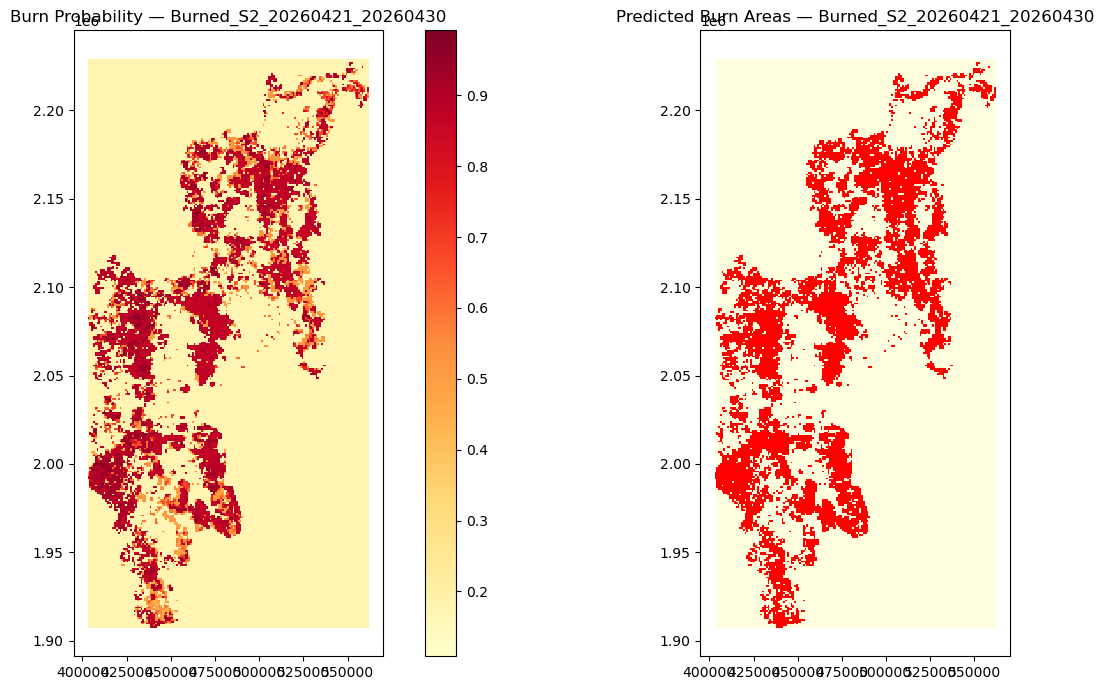

In [11]:
import matplotlib.pyplot as plt

grid['burn_prob'] = model.predict_proba(X)[:, 1]
grid['burn_pred'] = model.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

grid.plot(column='burn_prob', cmap='YlOrRd', legend=True, ax=axes[0])
axes[0].set_title(f'Burn Probability — {target_period}')

grid[grid['burn_pred'] == 1].plot(color='red', ax=axes[1])
grid[grid['burn_pred'] == 0].plot(color='lightyellow', ax=axes[1])
axes[1].set_title(f'Predicted Burn Areas — {target_period}')

plt.tight_layout()
plt.show()

1. Classification Report
              precision    recall  f1-score   support

 ไม่ไหม้ (0)       0.98      0.85      0.91      9226
    ไหม้ (1)       0.37      0.82      0.51      1014

    accuracy                           0.84     10240
   macro avg       0.67      0.83      0.71     10240
weighted avg       0.92      0.84      0.87     10240


2. Spatial Metrics
IoU  (ทับซ้อนจริง):        0.3389  → สูงยิ่งดี (>0.3 = ใช้ได้, >0.5 = ดี)
Recall (จับพื้นที่ไหม้ได้): 0.8156  → ไม่อยากพลาดจุดไหม้จริง
Precision (ทายแม่น):        0.3671  → ไม่อยากเตือนผิด
AUC-ROC:                    0.8575


/home/jupyter-chotika_kamsean@cm-8699d/.local/lib/python3.8/site-packages/geopandas/plotting.py:489: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from current font.
  plt.draw()
/home/jupyter-chotika_kamsean@cm-8699d/.local/lib/python3.8/site-packages/geopandas/plotting.py:489: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from current font.
  plt.draw()
/home/jupyter-chotika_kamsean@cm-8699d/.local/lib/python3.8/site-packages/geopandas/plotting.py:489: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from current font.
  plt.draw()
/home/jupyter-chotika_kamsean@cm-8699d/.local/lib/python3.8/site-packages/geopandas/plotting.py:489: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from current font.
  plt.draw()
/home/jupyter-chotika_kamsean@cm-8699d/.local/lib/python3.8/site-packages/geopandas/plotting.py:489: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from current font.
  plt.draw()
/opt/tljh/user/lib/python

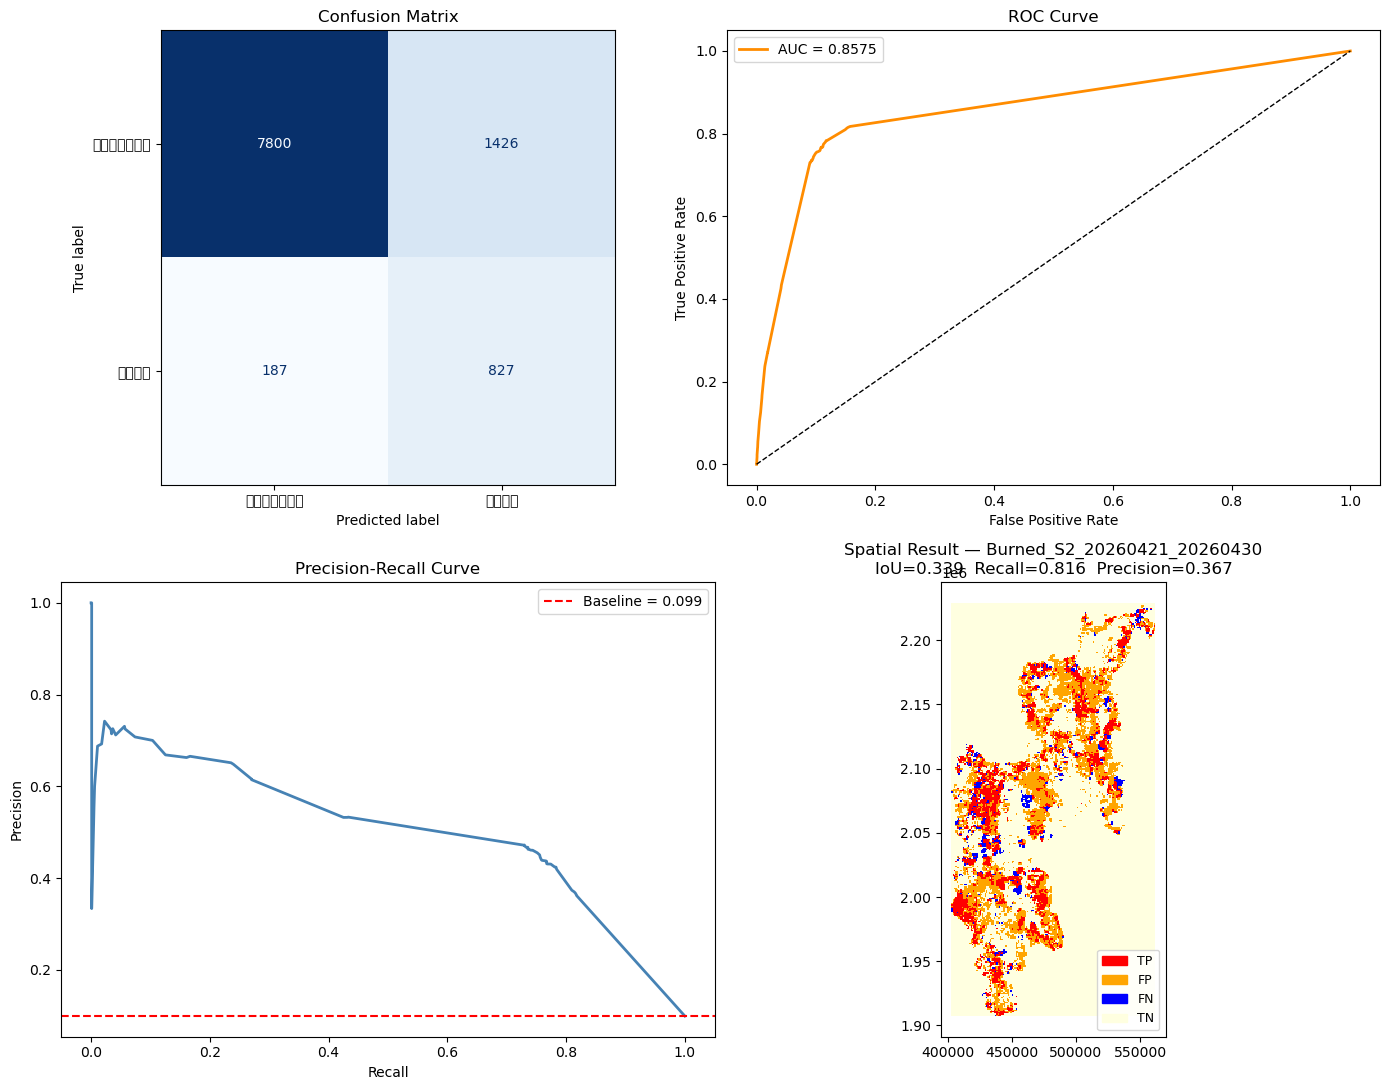

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve
)

# --- predictions ---
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# ============================================================
# 1. F1 / Precision / Recall
# ============================================================
print("=" * 50)
print("1. Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred,
      target_names=['ไม่ไหม้ (0)', 'ไหม้ (1)']))

# ============================================================
# 2. IoU (Intersection over Union) — spatial metric
# ============================================================
TP = ((y_pred == 1) & (y_test == 1)).sum()
FP = ((y_pred == 1) & (y_test == 0)).sum()
FN = ((y_pred == 0) & (y_test == 1)).sum()
TN = ((y_pred == 0) & (y_test == 0)).sum()

iou      = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0
recall   = TP / (TP + FN)      if (TP + FN) > 0 else 0   # = spatial accuracy
precision = TP / (TP + FP)     if (TP + FP) > 0 else 0

print(f"\n{'=' * 50}")
print("2. Spatial Metrics")
print(f"{'=' * 50}")
print(f"IoU  (ทับซ้อนจริง):        {iou:.4f}  → สูงยิ่งดี (>0.3 = ใช้ได้, >0.5 = ดี)")
print(f"Recall (จับพื้นที่ไหม้ได้): {recall:.4f}  → ไม่อยากพลาดจุดไหม้จริง")
print(f"Precision (ทายแม่น):        {precision:.4f}  → ไม่อยากเตือนผิด")
print(f"AUC-ROC:                    {roc_auc_score(y_test, y_proba):.4f}")

# ============================================================
# 3. Visualize — 4 กราฟ
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# --- 3.1 Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['ไม่ไหม้', 'ไหม้'])
disp.plot(ax=axes[0, 0], cmap='Blues', colorbar=False)
axes[0, 0].set_title('Confusion Matrix')

# --- 3.2 ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score   = roc_auc_score(y_test, y_proba)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2,
                label=f'AUC = {auc_score:.4f}')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend()

# --- 3.3 Precision-Recall Curve ---
prec, rec, thresholds = precision_recall_curve(y_test, y_proba)
axes[1, 0].plot(rec, prec, color='steelblue', lw=2)
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].axhline(y=y_test.mean(), color='red', linestyle='--',
                    label=f'Baseline = {y_test.mean():.3f}')
axes[1, 0].legend()

# --- 3.4 Spatial: ทายถูก/ผิด บน grid แผนที่ ---
grid_eval = grid.copy()
grid_eval['y_true'] = df[target_period].values
grid_eval['y_pred'] = model.predict(X)

def label_cell(row):
    if row['y_true'] == 1 and row['y_pred'] == 1: return 'TP'
    if row['y_true'] == 0 and row['y_pred'] == 1: return 'FP'
    if row['y_true'] == 1 and row['y_pred'] == 0: return 'FN'
    return 'TN'

grid_eval['result'] = grid_eval.apply(label_cell, axis=1)

color_map = {'TP': 'red', 'FP': 'orange', 'FN': 'blue', 'TN': 'lightyellow'}
grid_eval['color'] = grid_eval['result'].map(color_map)
grid_eval.plot(color=grid_eval['color'], ax=axes[1, 1], linewidth=0.1)

patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
axes[1, 1].legend(handles=patches, loc='lower right', fontsize=9)
axes[1, 1].set_title(f'Spatial Result — {target_period}\n'
                      f'IoU={iou:.3f}  Recall={recall:.3f}  Precision={precision:.3f}')

plt.tight_layout()
plt.show()